# Лабораторна робота №1 : Класифікація


**Мета:** Реалізувати програмно алгоритми класифікації 1-Rule, Naive Bayes, Decision Tree, kNN. Провести детальню попередню підготовку та обробку даних обраного датасету. Дослідити результат навчання кожного класифікатора, зробити висновок про доцільність використання того чи іншого класифікатора та вплив гіперпараметрів. Провести порівняльний аналіз отриманих класифікаторів.

**Датасет:** Статистика вживаних авто на ринку Великобританії (URL: https://www.kaggle.com/datasets/meruvulikith/90000-cars-data-from-1970-to-2024)

**Задача:** Класифікувати автомобілі за класом витрат палива (Poor, Efficient, Excellent).

## Зміст
1. [Data Clearing](#data_clearing)
2. [Models Training](#model_training)
    - [1-Rule](#one_rule)
    - [Naive Bayes](#naive_bayes)
    - [Decision Tree](#decision_tree)
    - [k-Nearest Neighbors](#knn)
3. [Results](#results)

**Імпортування необхідних бібліотек та датасету**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv("CarsData.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
0,I10,2017,7495,Manual,11630,Petrol,145,60.1,1.0,hyundi
1,Polo,2017,10989,Manual,9200,Petrol,145,58.9,1.0,volkswagen
2,2 Series,2019,27990,Semi-Auto,1614,Diesel,145,49.6,2.0,BMW
3,Yeti Outdoor,2017,12495,Manual,30960,Diesel,150,62.8,2.0,skoda
4,Fiesta,2017,7999,Manual,19353,Petrol,125,54.3,1.2,ford


**Виведемо загальну інформацію про датасет, його поля, їх к-сть та тип.**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97712 entries, 0 to 97711
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         97712 non-null  object 
 1   year          97712 non-null  int64  
 2   price         97712 non-null  int64  
 3   transmission  97712 non-null  object 
 4   mileage       97712 non-null  int64  
 5   fuelType      97712 non-null  object 
 6   tax           97712 non-null  int64  
 7   mpg           97712 non-null  float64
 8   engineSize    97712 non-null  float64
 9   Manufacturer  97712 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 7.5+ MB


__Можна побачити, що в датасеті присутні категоріальні та числові дані__

**Категоріальні (Номінальні)**:
   - **model**: Модель авто (M3, Fiesta, etc.);
   - **transmission**: Тип КПП (Manual, Semi-Auto, Automatic);
   - **fuelType**: Тип пального (Petrol, Diesel, Hybrid, Electric, Other);
   - **manufacturer**: Виробник (BMW, Hyundai, etc.)

**Числові**
   - **year**: Рік виготовлення(1970-2024);
   - **price**: Ціна продажу(У фунтах стерлінга);
   - **mileage**: Пробіг у милях;
   - **tax**: Річний податок(залежить від багатьох показників авто);
   - **mpg**: Розхід пального у милях на галон;
   - **engineSize**: Об'єм двигуна у літрах;

<div class="alert alert-block alert-info">
Можна побачити що кількість значень у датасеті для кожної з колонок є однаковою та дорівнює кількості записів, що виключає наявність значень типу NULL, проте це не гарантує відсутність дублікатів.
</div>

In [4]:
df = df.drop_duplicates()
df.shape

(97712, 10)

**Виведемо опис числових даних датасету щоб визначити потенційні проблеми з даними**

In [5]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000,97712.000000
mean,2017.066502,16773.487555,23219.475499,120.142408,55.205623,1.664913
std,2.118661,9868.552222,21060.882301,63.357250,16.181659,0.558574
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000
50%,2017.000000,14470.000000,17682.500000,145.000000,54.300000,1.600000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000
max,2024.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


<div class="alert alert-block alert-info">
На даному етапі можна помітити потенційні проблеми з датасетом та деякими його значеннями. Мінімальним значенням для engineSize є 0, що є неможливим у реальномі світі та пов'язане або з наявністю автомобілів класу Electric, або ж пустуючими даними. Мінімальні та максимальні значення для центрального показника, який буде використаний для класифікації, mpg, також є підозрілими та схожими на викиди, адже що значення 0.3, що 470 є недосяжними для будь-якого розповсюдженого типу автомобільного транспорту
</div>

**Використаємо коробкову діаграму щоб визначити розподіл витрат палива для кожного з типів пального:**

<AxesSubplot:title={'center':'mpg'}, xlabel='fuelType'>

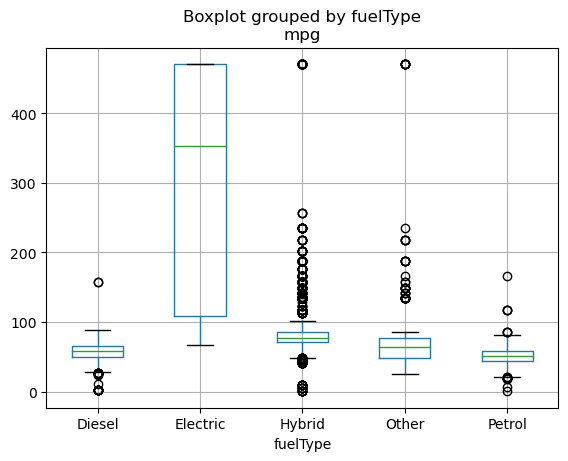

In [6]:
df.boxplot(column = "mpg", by = "fuelType")

<div class="alert alert-block alert-info">
Згідно з цим графіком можна побачити що в датасеті присутня велика кількість викидів та нереалістичних даних. Також при ручному дослідженні, було виявлено що в категорії <b>Other</b> знаходяться автомобілі, які потрібно було б віднести до інших представлених категорій, але схоже що при зборі інформації дані були отримані неправильно. Для більш об'єктивного аналізу та навчання, клас автомоболів <b>Electric</b> буде виключено з датасету, адже його порівняння з ДВЗ є необє'ктивним. Також буде виключено класс <b>Other</b>, через неможливість надійної рекласифікації екземплярів цього класу.
    </div>

<div class="alert alert-block alert-info">
Логічним кроком на даному етапі також буде виключення автомобілів з розходом менше 5 mpg (Даний показник є близьким до витрат палива танком, а отже нереалістичним для будь-яких дорожніх авто) та автомобілів з об'ємом двигуна 0.
</div>

<a id="data_clearing"></a>
# Data Clearing

In [7]:
df = df[(df['fuelType'] != 'Other') & (df['fuelType'] != 'Electric')]
df = df[df['mpg'] > 5]
df = df[df['engineSize'] > 0]

<AxesSubplot:title={'center':'mpg'}, xlabel='fuelType'>

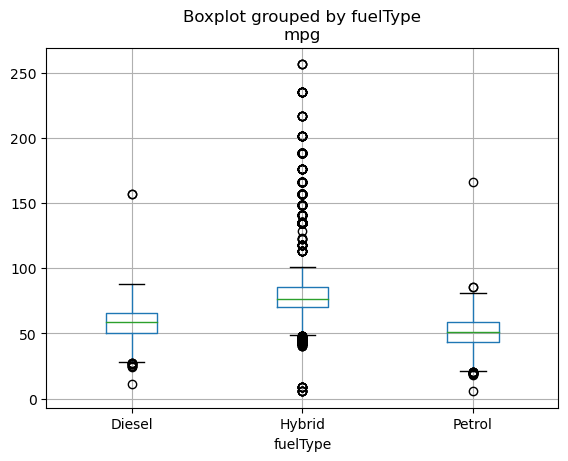

In [8]:
df.boxplot(column = "mpg", by = "fuelType")

<div class="alert alert-block alert-info">
Далі викорисовуючи формулу міжквартального розмаху (Interquartile range), яка покладена в основу коробкових діаграм,
    виключимо з датасету викиди, які знаходяться занадто далеко від 25% та 75% квартилю (Значення що лежать за межами вус на діаграмі зверху).
</div>

<AxesSubplot:title={'center':'mpg'}, xlabel='fuelType'>

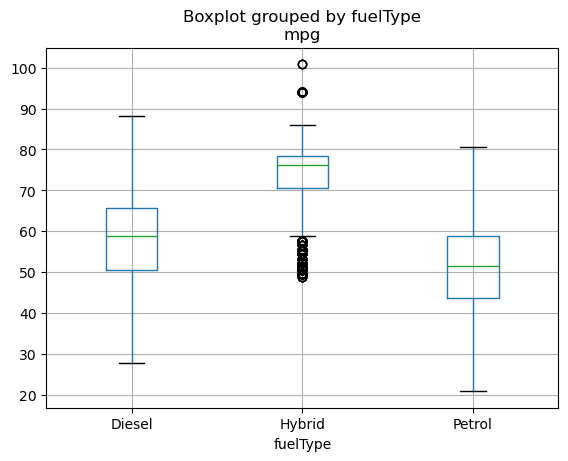

In [9]:
def remove_outliers(data, category, relation):
    clean_data = []
    for fuel in data[relation].unique():
        set = data[data[relation] == fuel]
        Q1 = set[category].quantile(0.25)
        Q3 = set[category].quantile(0.75)
        IQR = Q3 - Q1
        
        low = Q1 - 1.5 * IQR
        high = Q3 + 1.5 * IQR
        
        filtered_set = set[(set[category] >= low) & (set[category] <= high)]
        clean_data.append(filtered_set)
    return pd.concat(clean_data)

df_filtered = remove_outliers(df, 'mpg', 'fuelType')
df_filtered.boxplot(column = "mpg", by = "fuelType")

<div class="alert alert-block alert-warning">
В отримананому на виході відфільтрованому датасеті можемо побачити що для класів <b>Diesel</b> та <b>Petrol</b>, усі значення знаходяться в прийнятних межах та не мають жодних викидів. У класі <b>Hybrid</b> все ще присутні викиди, при цьому більша їх частина знаходиться у нижній частині графіку, що можна пояснити належністю до категорії гібридних авто як звичайних, так і Plug-In гібридів, які в середньому мають більш оптимістичні показники пробігу від виробника, що впливає на розподіл.
Це не є проблемою, скоріше особливістю предметної сфери.
</div>

<div class="alert alert-block alert-info">
Після видалення викидів за показником mpg, створимо новий стопвчик з класом розходу палива відповідно до показника mpg. Розподіл відбувається на 3 класи: <b>Poor</b>, <b>Efficient</b>, <b>Excellent</b>
</div>

In [10]:
mpg_bin_constants = [0, 40, 60, 120]
mpg_bin_class_names = ["Poor", "Efficient", "Excellent"]
df_filtered["mpg_class"] = pd.cut(df_filtered['mpg'], bins = mpg_bin_constants, labels = mpg_bin_class_names)
df_filtered["mpg_class"].value_counts(normalize = True)

Efficient    0.538539
Excellent    0.350028
Poor         0.111433
Name: mpg_class, dtype: float64

<div class="alert alert-block alert-warning">
Утворений розподіл є незбалансованим<br>
    <b>Excellent:</b> 35% <br>
    <b>Efficient:</b> 53%<br>
    <b>Poor:</b> 11%<br>
    
Причиною цього є використання меж поділу на класи, які мають сенс для предметної області та умов реального світу, використання статистично рівного розподілу на класи протиречило би цілі застосування датасету. В подальшому, цей дисбаланс буде враховано при тренуванні алгоритмів класифікаторів.
</div>

**Видалення записів автомобілів, ціна яких сильно відрізняється від середньої по моделі**

In [11]:
df_filtered = remove_outliers(df_filtered, 'price', 'model')

In [12]:
len(df_filtered)

94336

**Видалимо автомобілі старше 2000 року, адже вони складають статистично незначну частину датасету, при цьому можуть сильно впливати на навчання моделей в майбутньому**

<AxesSubplot:title={'center':'year'}, xlabel='Manufacturer'>

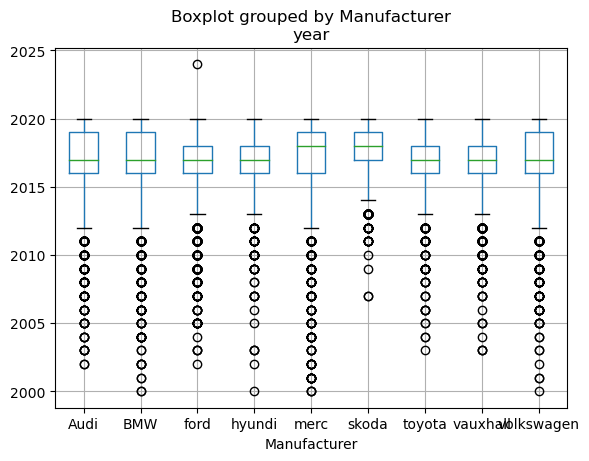

In [13]:
df_filtered = df_filtered[df_filtered['year'] >= 2000]
df_filtered.boxplot(column = "year", by = "Manufacturer")

In [14]:
len(df_filtered)

94320

**Наступним кроком потрібно визначити загальний розподіл пробігу відносно року випуску, та наявність викидів за цим параметром**

<AxesSubplot:title={'center':'mileage'}, xlabel='year'>

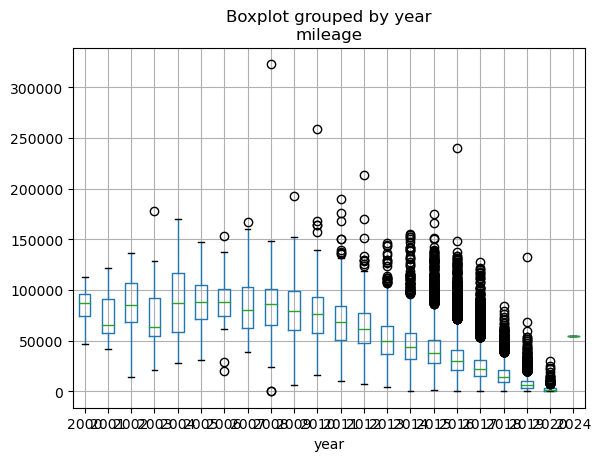

In [15]:
df_filtered.boxplot(column = "mileage", by = "year")

<div class="alert alert-block alert-info">
Можна побачити що більш нові авто в середньому мають менший пробіг, але більшу кількість викидів, що скоріш за все пов'язано з більш екстримальними умовами використання такими як служба в таксі.  
</div>

<AxesSubplot:title={'center':'mileage'}, xlabel='year'>

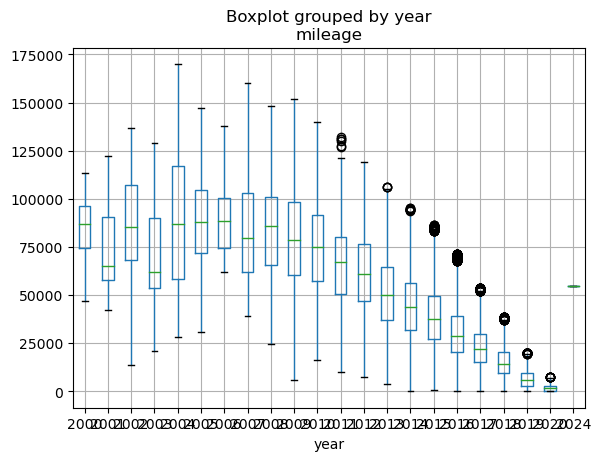

In [16]:
df_filtered = remove_outliers(df_filtered, 'mileage', 'year')
df_filtered.boxplot(column = "mileage", by = "year")

In [17]:
len(df_filtered)

92067

<div class="alert alert-block alert-info">
Після очищення було втрачено ~2300 записів, що не є критичним, проте дозволить покращити точність навчання
</div>

<AxesSubplot:title={'center':'engineSize'}, xlabel='fuelType'>

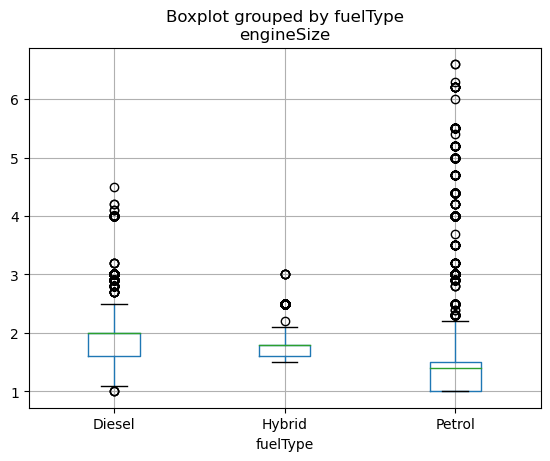

In [18]:
df_filtered.boxplot(column = "engineSize", by = "fuelType")

<div class="alert alert-block alert-warning">
    Незважаючи на наявність "викидів" за показником <b>engineSize</b>, насправді ж це є нормальним розподілом характеристик автомобілів для кожного з типів ДВЗ. Важливим моментом також є те, що автомобілі з об'ємом двигуна більше 3, мають дуже високу вірогідність опинитися у категорії <b>Poor</b>, якщо прибрати їх як викиди, то дисбаланс у класах зросте ще більше.
</div>

**Наступним кроком створимо матрицю лінійної кореляції для числових параметрів датасету**

<AxesSubplot:>

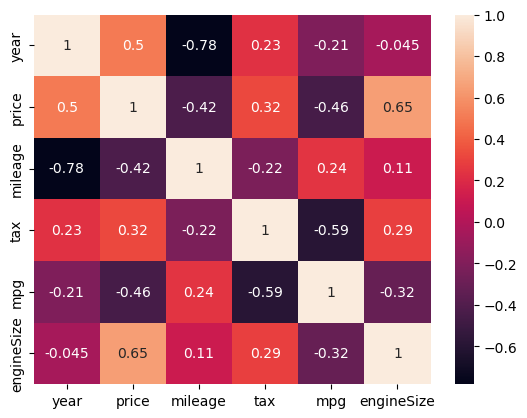

In [19]:
sns.heatmap(df_filtered.select_dtypes(include='number').corr(), annot=True)

<div class="alert alert-block alert-info">
Можна побачити логічні залежності <b>mpg</b> від інших показників. Збільшення <b>price</b> <b>engineSize</b> та <b>tax</b> мають єдине джерело - більш дорогі, потужні автомобілі мають гірші показники розходу та вищі показники податку. Інші цікаві залежності: зменшення віку призводить до збільшення ціни, збільшення віку авто призводить до збільшення пробігу.
</div>

**Створимо скрипкові діаграми щоб проаналізувати залежність різних показників та визначимо найкращі показники для класифікаторів**

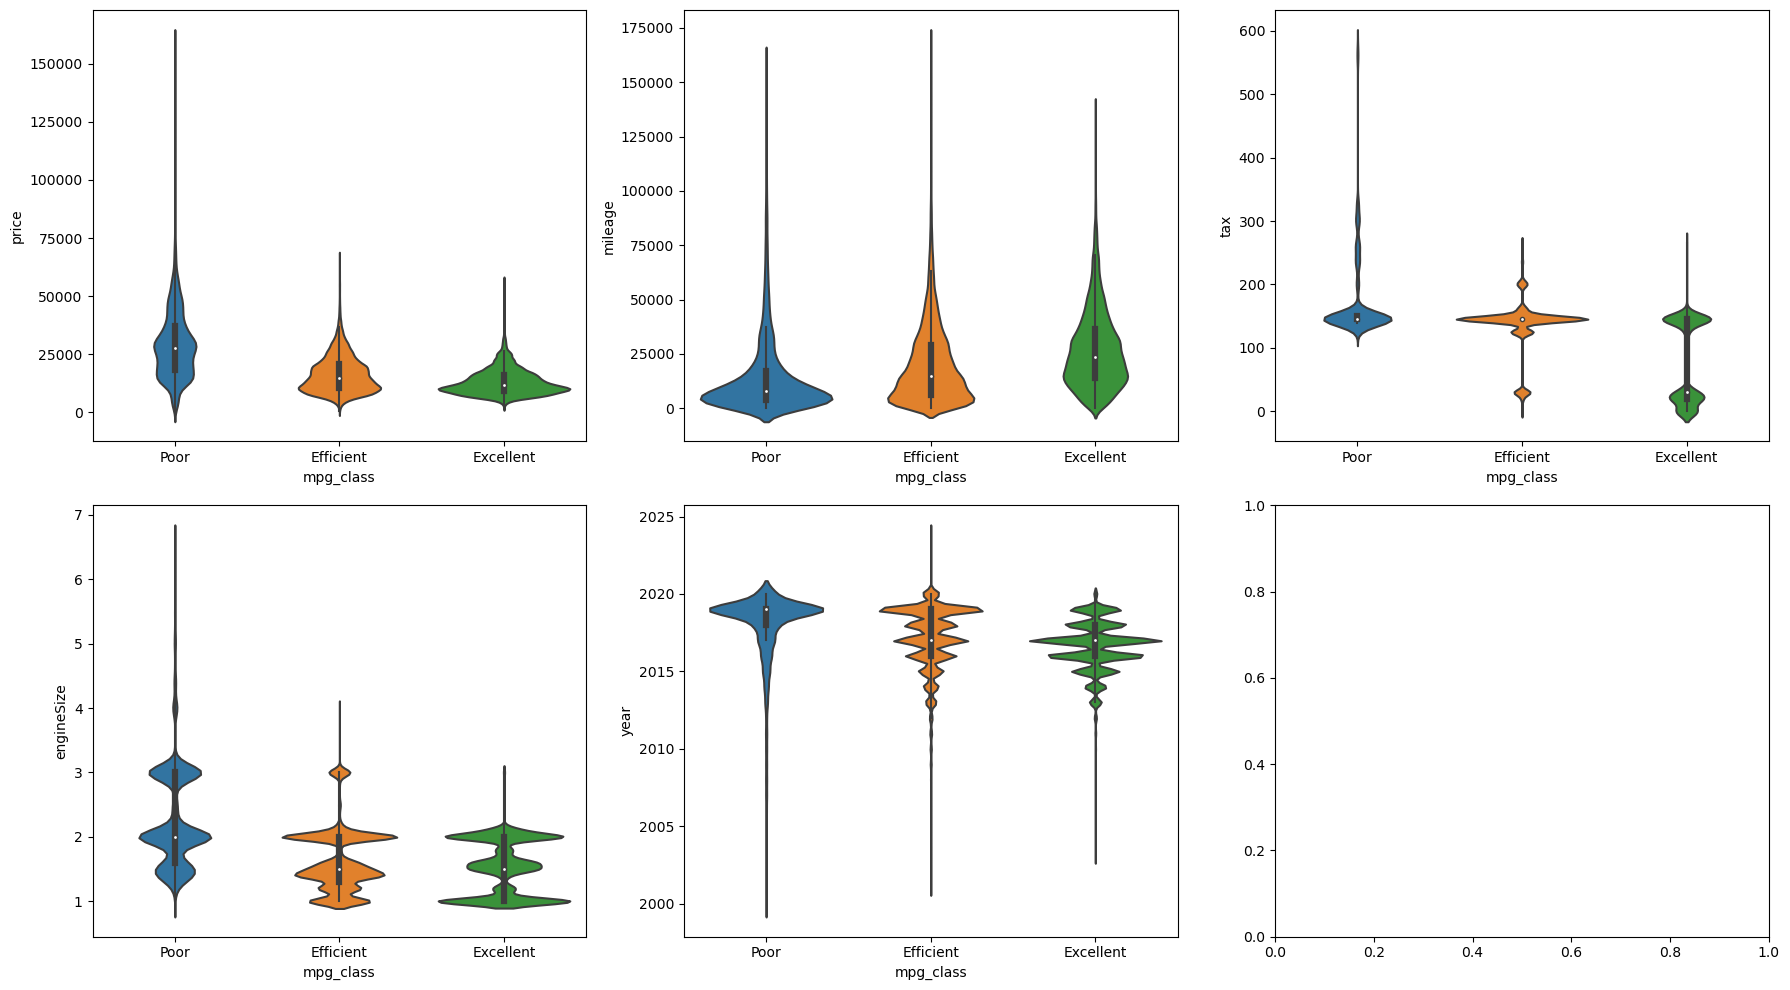

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), ['price', 'mileage', 'tax', 'engineSize', 'year']):
    sns.violinplot(x='mpg_class', y=col, data=df_filtered, ax = ax)
plt.tight_layout()

<div class="alert alert-block alert-info">
Проаналізувавши дані діаграми, <b>price</b> <b>engineSize</b> та <b>tax</b> є особливо ефективним для визначення автомобілів класу <b>Poor</b>. <b>engineSize</b> та <b>tax</b> також допомагають добре виокремлювати екземпляри класу <b>Excellent</b>.
</div>

**Перед тим як перейти до тренування моделей, необхідно перевірити показник відхилення числових даних датасету**

In [21]:
df_filtered.skew(numeric_only = True)

year         -1.497265
price         2.080929
mileage       1.406597
tax          -0.071613
mpg           0.059897
engineSize    1.337153
dtype: float64

<div class="alert alert-block alert-info">
Значення перехилу більші за -+0.5 вважаються високими, через що вони можуть значно впливати на показники ефективності алгоритмів які покладаються на дистанцію між змінними, наприклад kNN. Щоб зменшити відхилення, обробимо дані за допомогою логарифмічної або квадратичної функції перетворення.
</div>

In [22]:
df_filtered['log_price'] = np.log1p(df_filtered['price'])
df_filtered['sqrt_mileage'] = np.sqrt(df_filtered['mileage'])
df_filtered['log_engineSize'] = np.log1p(df_filtered['engineSize'])
df_filtered['log_age'] = np.log1p(2024 - df_filtered['year'])

df_filtered = df_filtered.drop(columns = ['mileage', 'price', 'year', 'engineSize'])
df_filtered.skew(numeric_only = True)

tax              -0.071613
mpg               0.059897
log_price         0.051498
sqrt_mileage      0.223476
log_engineSize    0.534395
log_age           0.470048
dtype: float64

<div class="alert alert-block alert-info">
Тепер відхилення для числових змінних є прийнятним. Перевіримо розподіл записів по екземплярам класів які є ціллю класифікації.
</div>

In [23]:
df_filtered["mpg_class"].value_counts(normalize = True)

Efficient    0.544419
Excellent    0.350918
Poor         0.104663
Name: mpg_class, dtype: float64

<div class="alert alert-block alert-info">
Пропорції класів змінились незначно. Наступним кроком буде застосування методу One-Hot Encoding для категоріальних змінних <b>Manufacturer</b>, <b>transmission</b>, <b>fuelType</b>, вони мають незначну кількість унікальних значень (9, 4 та 3 відповідно). Змінну <b>model</b> буде видалено з датасету, адже вона має 190+ унікальних значень та являє собою в тому чи іншому виді компіляцію інших числових та категоріальних змінних які вже присутні в датасеті.
</div>

In [24]:
df_filtered = pd.get_dummies(df_filtered, columns = ['Manufacturer', 'transmission', 'fuelType'] )

In [25]:
df_filtered = df_filtered.drop(columns = ['model'])

In [26]:
df_filtered = df_filtered.drop(columns = ['mpg'])

<a id="model_training"></a>
# Models Training

**Виконаємо поділ датасету на вибірки Training/Validation/Testing за класичним розподілом 60/20/20**

In [27]:
X = df_filtered.drop(columns=['mpg_class'])
Y = df_filtered['mpg_class']

X_trainingpart, X_test, Y_trainingpart, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 393, stratify = Y)

X_train, X_val, Y_train, Y_val = train_test_split(X_trainingpart, Y_trainingpart, test_size = 0.25, random_state = 393, stratify = Y_trainingpart)

print(X_train.shape, X_val.shape, X_test.shape)

(55239, 21) (18414, 21) (18414, 21)


**Проведемо масштабування змінних та перевіримо розподіл класів по вибіркам**

In [28]:
num_cols = ['tax', 'log_price', 'log_engineSize', 'log_age', 'sqrt_mileage']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] =   scaler.transform(X_val[num_cols])
X_test[num_cols] =  scaler.transform(X_test[num_cols])

split_stats = [('Train', Y_train), ('Validation', Y_val), ('Test', Y_test)]

for set_name, Y_split in split_stats:
    print(f"{set_name}:\n{Y_split.value_counts(normalize=True)}\n")

Train:
Efficient    0.544416
Excellent    0.350911
Poor         0.104672
Name: mpg_class, dtype: float64

Validation:
Efficient    0.544423
Excellent    0.350929
Poor         0.104649
Name: mpg_class, dtype: float64

Test:
Efficient    0.544423
Excellent    0.350929
Poor         0.104649
Name: mpg_class, dtype: float64



<a id="one_rule"></a>
# 1-Rule

Top feature: tax
Split threshold: -1.5191

Validation accuracy: 0.6776
Test accuracy: 0.6794

Classification Metrics:
              precision    recall  f1-score   support

   Efficient       0.63      0.99      0.77     10025
   Excellent       0.96      0.40      0.57      6462
        Poor       0.00      0.00      0.00      1927

    accuracy                           0.68     18414
   macro avg       0.53      0.46      0.45     18414
weighted avg       0.68      0.68      0.62     18414



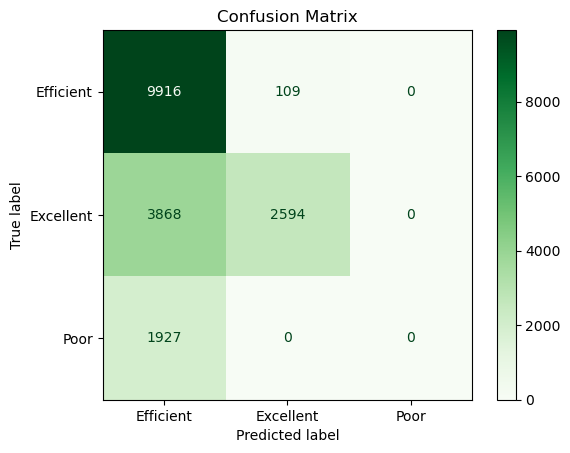

In [29]:
one_rule = DecisionTreeClassifier(max_depth = 1, random_state = 393)
one_rule.fit(X_train, Y_train)

one_val_preds = one_rule.predict(X_val)
one_test_preds = one_rule.predict(X_test)
print(f"Top feature: {X_train.columns[one_rule.tree_.feature[0]]}")
print(f"Split threshold: {one_rule.tree_.threshold[0]:.4f}")
print(f"\nValidation accuracy: {accuracy_score(Y_val, one_val_preds):.4f}")
print(f"Test accuracy: {accuracy_score(Y_test, one_test_preds):.4f}")
print("\nClassification Metrics:")
print(classification_report(Y_test, one_test_preds, zero_division = 0))

cm = confusion_matrix(Y_test, one_test_preds, labels = one_rule.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= one_rule.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix')
plt.show()

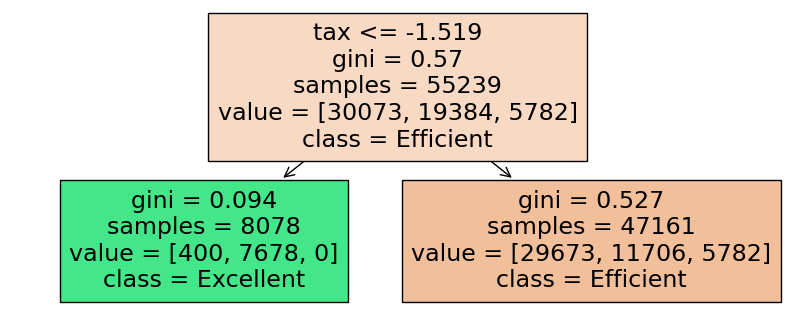

In [30]:
plt.figure(figsize=(10, 4))
plot_tree(one_rule, feature_names=X_train.columns, class_names=one_rule.classes_, filled=True)
plt.show()

Top feature: tax
Split threshold: -0.8006

Validation accuracy: 0.2873
Test accuracy: 0.2922

Classification Metrics:
              precision    recall  f1-score   support

   Efficient       0.00      0.00      0.00     10025
   Excellent       0.79      0.53      0.64      6462
        Poor       0.14      1.00      0.24      1927

    accuracy                           0.29     18414
   macro avg       0.31      0.51      0.29     18414
weighted avg       0.29      0.29      0.25     18414



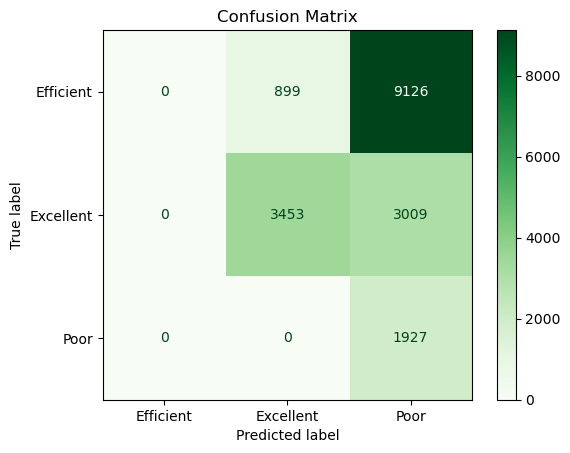

In [31]:
one_rule_balanced = DecisionTreeClassifier(max_depth = 1, random_state = 393, class_weight='balanced')
one_rule_balanced.fit(X_train, Y_train)

oneb_val_preds = one_rule_balanced.predict(X_val)
oneb_test_preds = one_rule_balanced.predict(X_test)
print(f"Top feature: {X_train.columns[one_rule_balanced.tree_.feature[0]]}")
print(f"Split threshold: {one_rule_balanced.tree_.threshold[0]:.4f}")
print(f"\nValidation accuracy: {accuracy_score(Y_val, oneb_val_preds):.4f}")
print(f"Test accuracy: {accuracy_score(Y_test, oneb_test_preds):.4f}")
print("\nClassification Metrics:")
print(classification_report(Y_test, oneb_test_preds, zero_division = 0))

cm = confusion_matrix(Y_test, oneb_test_preds, labels=one_rule_balanced.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= one_rule_balanced.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix')
plt.show()

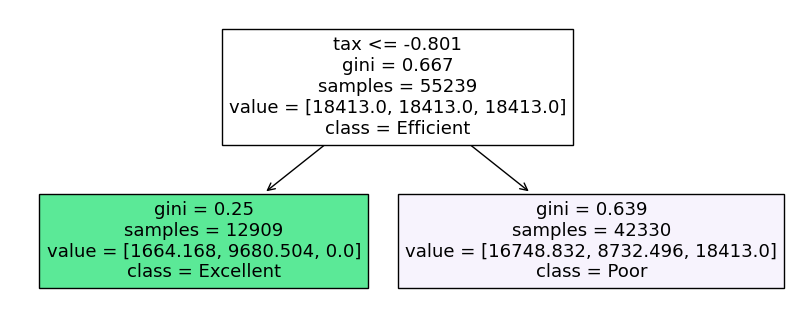

In [32]:
plt.figure(figsize=(10, 4))
plot_tree(one_rule_balanced, feature_names=X_test.columns, class_names=one_rule_balanced.classes_, filled=True)
plt.show()

<a id="bayes"></a>
# Naive Bayes

Validation accuracy: 0.6793
Test accuracy: 0.6801

Classification Report:
              precision    recall  f1-score   support

   Efficient       0.70      0.73      0.72     10025
   Excellent       0.73      0.63      0.68      6462
        Poor       0.46      0.57      0.51      1927

    accuracy                           0.68     18414
   macro avg       0.63      0.64      0.63     18414
weighted avg       0.69      0.68      0.68     18414



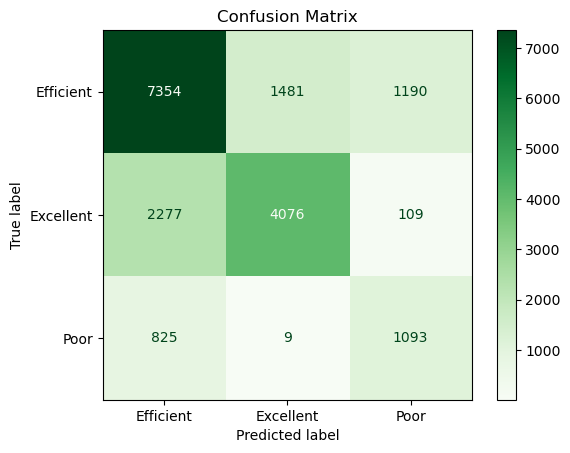

In [33]:
gaussian_cols = ['log_price', 'sqrt_mileage', 'log_engineSize', 'log_age', 'tax']
bernoulli_cols = [col for col in X_train.columns if col not in gaussian_cols]

g_idx = [X_train.columns.get_loc(c) for c in gaussian_cols]
b_idx = [X_train.columns.get_loc(c) for c in bernoulli_cols]

g_bayes = GaussianNB()
b_bayes = BernoulliNB()

g_bayes.fit(X_train[gaussian_cols], Y_train)
b_bayes.fit(X_train[bernoulli_cols], Y_train)

g_log = g_bayes.predict_log_proba(X_test[gaussian_cols])
b_log = b_bayes.predict_log_proba(X_test[bernoulli_cols])

g_log_val = g_bayes.predict_log_proba(X_val[gaussian_cols])
b_log_val = b_bayes.predict_log_proba(X_val[bernoulli_cols])

prior = np.log(g_bayes.class_prior_)

combined = g_log + b_log - prior
combined_val = g_log_val + b_log_val - prior
bayes_test_preds = g_bayes.classes_[np.argmax(combined, axis=1)]
bayes_val_preds = g_bayes.classes_[np.argmax(combined_val, axis=1)]

print(f"Validation accuracy: {accuracy_score(Y_val, bayes_val_preds):.4f}")
print(f"Test accuracy: {accuracy_score(Y_test, bayes_test_preds):.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, bayes_test_preds, zero_division = 0))

cm = confusion_matrix(Y_test, bayes_test_preds, labels = g_bayes.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = g_bayes.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix')
plt.show()

<a id="decision_tree"></a>
# Decision Tree

Tree depth: 39
Number of leaves: 5860
Validation accuracy: 0.8776
Test accuracy: 0.8795

Classification Report:
              precision    recall  f1-score   support

   Efficient       0.89      0.89      0.89     10025
   Excellent       0.89      0.88      0.88      6462
        Poor       0.82      0.81      0.81      1927

    accuracy                           0.88     18414
   macro avg       0.86      0.86      0.86     18414
weighted avg       0.88      0.88      0.88     18414



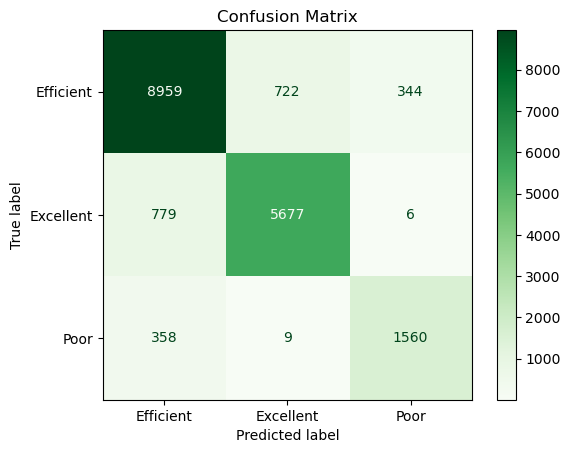

In [34]:
dt = DecisionTreeClassifier(random_state = 393)
dt.fit(X_train, Y_train)

dt_val_predicts = dt.predict(X_val)
dt_test_predicts = dt.predict(X_test)
print(f"Tree depth: {dt.get_depth()}")
print(f"Number of leaves: {dt.get_n_leaves()}")
print(f"Validation accuracy: {accuracy_score(Y_val, dt_val_predicts):.4f}")
print(f"Test accuracy: {accuracy_score(Y_test, dt_test_predicts):.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, dt_test_predicts, zero_division = 0))

cm = confusion_matrix(Y_test, dt_test_predicts, labels = dt.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = dt.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix')
plt.show()

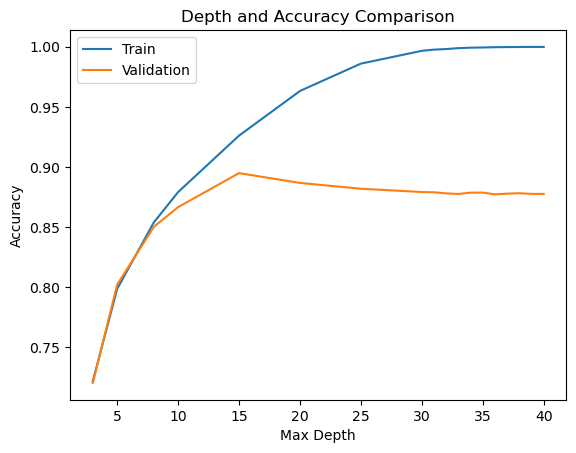

In [35]:
results = []
for depth in [3, 5, 8, 10, 15, 20, 25, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=393)
    dt_temp.fit(X_train, Y_train)
    train_acc = accuracy_score(Y_train, dt_temp.predict(X_train))
    val_acc = accuracy_score(Y_val, dt_temp.predict(X_val))
    results.append((depth, train_acc, val_acc))
    
depths, train_accs, val_accs = zip(*results)
plt.plot(depths, train_accs, label='Train')
plt.plot(depths, val_accs, label='Validation')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Depth and Accuracy Comparison')
plt.legend()
plt.show()

Tree depth: 15
Number of leaves: 1558
Validation accuracy: 0.8949
Test accuracy: 0.8948

Classification Report:
              precision    recall  f1-score   support

   Efficient       0.91      0.90      0.90     10025
   Excellent       0.89      0.91      0.90      6462
        Poor       0.85      0.81      0.83      1927

    accuracy                           0.89     18414
   macro avg       0.88      0.88      0.88     18414
weighted avg       0.89      0.89      0.89     18414



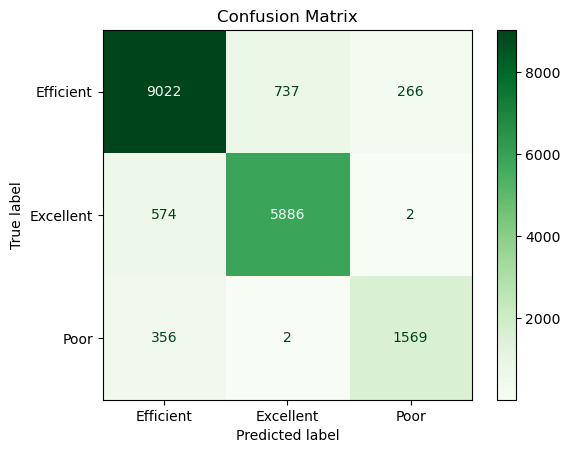

In [36]:
dt = DecisionTreeClassifier(max_depth = 15, random_state = 393)
dt.fit(X_train, Y_train)

dt_val_predicts = dt.predict(X_val)
dt_test_predicts = dt.predict(X_test)
print(f"Tree depth: {dt.get_depth()}")
print(f"Number of leaves: {dt.get_n_leaves()}")
print(f"Validation accuracy: {accuracy_score(Y_val, dt_val_predicts):.4f}")
print(f"Test accuracy: {accuracy_score(Y_test, dt_test_predicts):.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, dt_test_predicts, zero_division = 0))

cm = confusion_matrix(Y_test, dt_test_predicts, labels = dt.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = dt.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix')
plt.show()

<a id="knn"></a>
# k-Nearest Neighbors

C:\Users\Admin\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
C:\Users\Admin\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdim

Validation accuracy: 0.8899
Test accuracy: 0.8879

Classification Report:
              precision    recall  f1-score   support

   Efficient       0.90      0.90      0.90     10025
   Excellent       0.89      0.89      0.89      6462
        Poor       0.84      0.81      0.83      1927

    accuracy                           0.89     18414
   macro avg       0.88      0.87      0.87     18414
weighted avg       0.89      0.89      0.89     18414



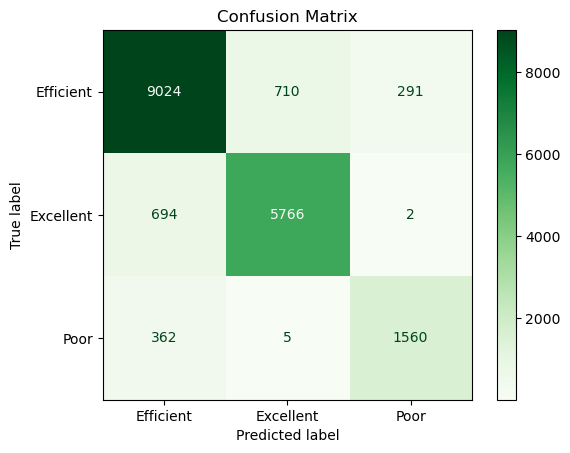

In [37]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, Y_train)

knn_val_preds = knn.predict(X_val)
knn_test_preds = knn.predict(X_test)

print(f"Validation accuracy: {accuracy_score(Y_val, knn_val_preds):.4f}")
print(f"Test accuracy: {accuracy_score(Y_test, knn_test_preds):.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, knn_test_preds, zero_division=0))
cm = confusion_matrix(Y_test, knn_test_preds, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix')
plt.show()

results = []<br>
for k in [1, 3, 5, 7, 11, 15, 21, 31, 51, 75, 101]:<br>
    knn_temp = KNeighborsClassifier(n_neighbors=k)<br>
    knn_temp.fit(X_train, Y_train)<br>
    train_acc = accuracy_score(Y_train, knn_temp.predict(X_train))<br>
    val_acc = accuracy_score(Y_val, knn_temp.predict(X_val))<br>
    results.append((k, train_acc, val_acc))<br>
    
k, train_accs, val_accs = zip(*results)<br>
plt.plot(k, train_accs, label='Train')<br>
plt.plot(k, val_accs, label='Validation')<br>
plt.xlabel('k Number')<br>
plt.ylabel('Accuracy')<br>
plt.title('k Number and Accuracy Comparison')<br>
plt.legend()<br>
plt.show()<br>
<img src = "kNN.png" title="Result"></img>

<a id="results"></a>
# Results

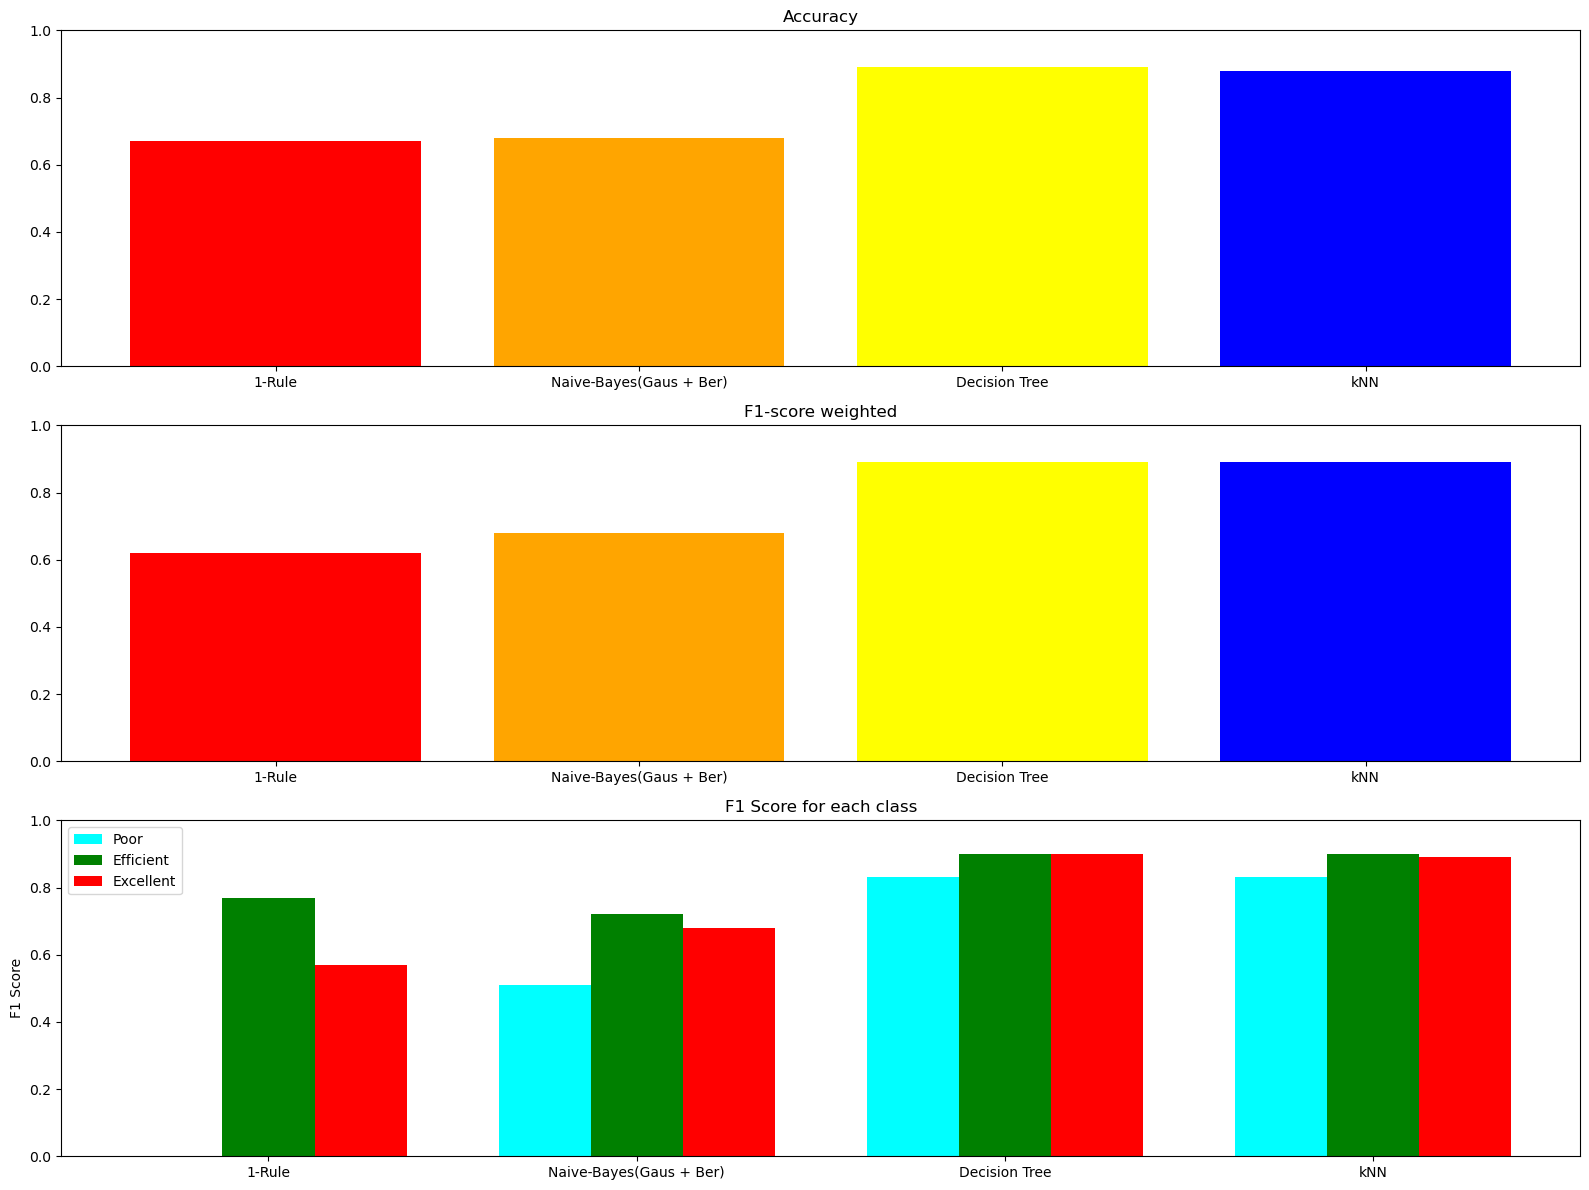

In [38]:
names = ['1-Rule', 'Naive-Bayes(Gaus + Ber)', 'Decision Tree', 'kNN']
acc = [0.67, 0.68, 0.89, 0.88]
f1_weighted = [0.62, 0.68, 0.89, 0.89]
f1_excellent = [0.57, 0.68, 0.90, 0.89]
f1_efficient = [0.77, 0.72, 0.90, 0.90]
f1_poor = [0.00, 0.51, 0.83, 0.83]

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
axes[0].bar(names, acc, label='Accuracy', color = ['red', 'orange', 'yellow', 'blue'])
axes[0].set_title("Accuracy")
axes[0].set_ylim(0,1)

axes[1].bar(names, f1_weighted, label='F1-score weighted', color = ['red', 'orange', 'yellow', 'blue'])
axes[1].set_title("F1-score weighted")
axes[1].set_ylim(0,1)

x = np.arange(len(names))
width = 0.25

axes[2].bar(x - width, f1_poor, width, label='Poor', color='cyan')
axes[2].bar(x, f1_efficient, width, label='Efficient', color='green')
axes[2].bar(x + width, f1_excellent, width, label='Excellent', color='red')
axes[2].set_title('F1 Score for each class')
axes[2].set_ylabel('F1 Score')
axes[2].set_xticks(x)
axes[2].set_xticklabels(names)
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
Підводячи підсумки, можна сказати що найефективнішими алгоритмами для цієї задачі є Decision Tree та kNN. 1-Rule погано пристосований для небінарної класифікації, через що він повністю ігнорує один з класів при передбаченні. Алгоритм Байеса не підходить для виконання поставленої задачі з декількох причин: змінні є залежними один від одної що протиречить суті алгоритму, змінні часто не мають нормального розподілу та змінні є нерівноправними. Decision Tree та kNN найркаще підходять для поставленого типу задач, що доказується показаними результатами, при цьому вони показали чудові результати незважаючи на нерівномірний розподіл класів.
</div>